# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ashley Tibebe

**Date:** 09/09/2026

My answer (calculation) to Question 1 are added to my github repo as a pdf document!

In [355]:
pip install pandas


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [356]:
pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [357]:
pip install numpy


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [358]:
import pandas as pd

In [359]:
import numpy as np

In [360]:
import matplotlib.pyplot as plt

In [361]:
pip install seaborn


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [362]:
import seaborn as sns

In [363]:
# Your Phase 1 solution to the problem goes here.
gift = pd.read_csv('ForeignGifts_edu.csv')

In [364]:
gift["Country of Giftor"].unique()

<StringArray>
[                'CHINA',               'ENGLAND',          'SAUDI ARABIA',
                'KUWAIT',               'GERMANY',                 'JAPAN',
                 'KOREA',                'TURKEY',                'SWEDEN',
               'BERMUDA',
 ...
               'BOLIVIA',           'EL SALVADOR',      'PAPUA NEW GUINEA',
               'TUNISIA',       'ST. KITTS-NEVIS',   'BRITISH WEST INDIES',
 'MARSHAL ISLANDS (THE)',               'CURAçAO',               'GRENADA',
               'ANTIGUA']
Length: 155, dtype: str

In [365]:
print ("gift.shape:")
print(gift.shape)
print("gift.dtypes:")
print(gift.dtypes)
gift.head()
#These codes allow me to take a quick look at the data and understand its general structure and data types.

gift.shape:
(28221, 10)
gift.dtypes:
ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


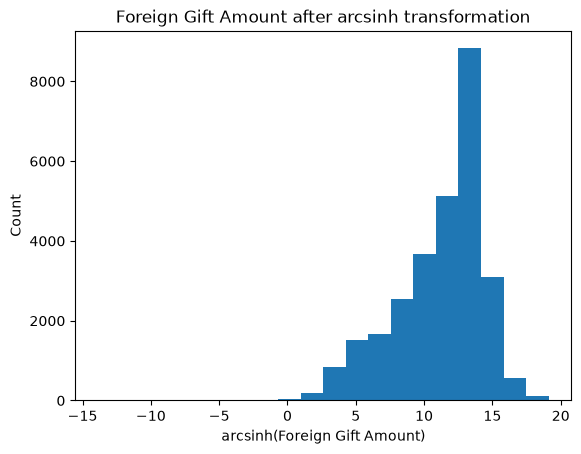

In [366]:
gift["Foreign_Gift_Amount_arcsinh"] = np.arcsinh(gift["Foreign Gift Amount"])

gift["Foreign_Gift_Amount_arcsinh"].hist(bins=20, grid=False)
plt.title("Foreign Gift Amount after arcsinh transformation")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()

To create this histogram, I decided to use the arcsinh transformation on the "Foreign Gift Amount" column to better visualize the data. At first, I did not use this function, and the data appeared extremely packed into one bin, making it hard to interpret. The arcsinh transformation allowed me to better see the spread of the data. From the histogram, I can see that the bins with the highest counts are the ones in between bins 10 and 15. On the other hand, the bins with the lowest counts are the ones in between bins 0 and 5 and 15 and 20. Therefore, most of the foreign gift amounts are concentrated in the middle range, while there are fewer gifts in the lower and higher ranges.

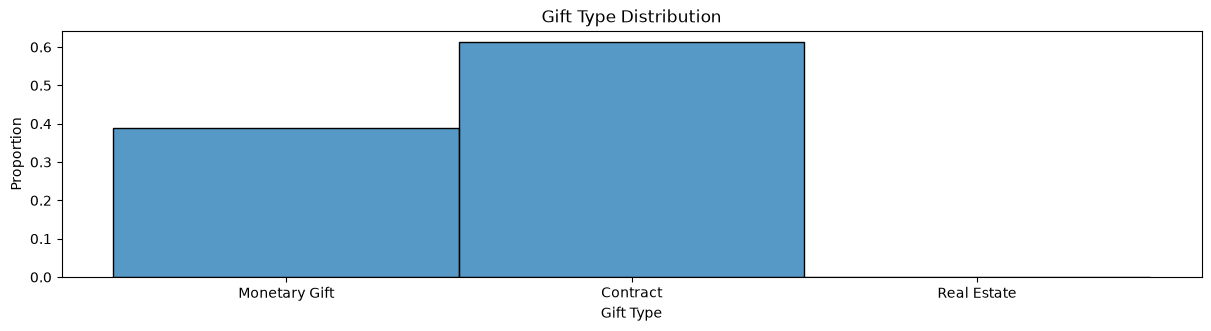

In [367]:
x = gift["Gift Type"].dropna().sample(28221, random_state=10).to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(12, 3.2), layout="constrained")
sns.histplot(data=gift, x="Gift Type", stat = "proportion", ax=ax)
ax.set(title="Gift Type Distribution", xlabel="Gift Type")
plt.show()

The proportion of Contract gift types in this data set is approximately 0.6 (60%), while the proportion of Monetary gift types is approximately 0.4 (40%). Laslty, the proportion of Real estate gift is too small to appear on this visualization.

In [368]:
x = pd.to_numeric(gift["Foreign Gift Amount"], errors='coerce').dropna().to_numpy()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


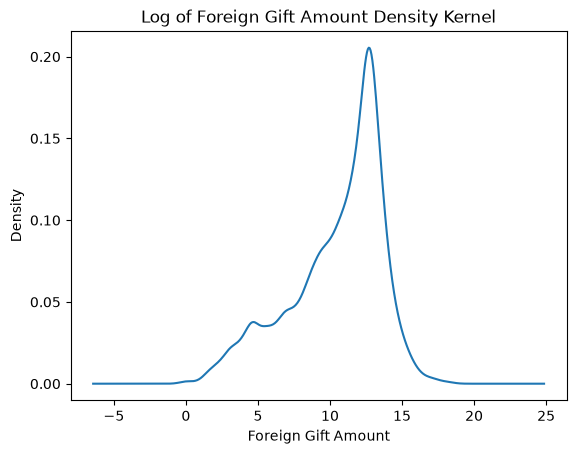

In [369]:
gift["Foreigngiftlog"] = np.log(gift["Foreign Gift Amount"].replace(0, np.nan))

x = gift["Foreigngiftlog"].dropna().to_numpy()
N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernel(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="Log of Foreign Gift Amount Density Kernel", xlabel="Foreign Gift Amount", ylabel="Density")
plt.show()

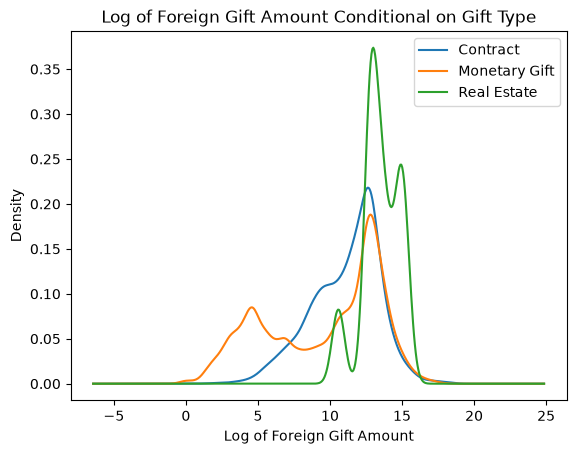

In [370]:
fig, ax = plt.subplots()
for gift_type, group in gift.groupby("Gift Type"):
    x_sub = group["Foreigngiftlog"].dropna().to_numpy()
    N_sub = len(x_sub)
    estimate = sum(normal_kernel(value, h_s) for value in x_sub) / N_sub
    sns.lineplot(x=grid, y=estimate, label=str(gift_type), ax=ax)
ax.set(title="Log of Foreign Gift Amount Conditional on Gift Type", xlabel="Log of Foreign Gift Amount", ylabel="Density")
plt.show()

One Pattern I noticed is that all gift types tend to increase in density beween the log values of approximately 10 and 15. Additionally, all of the lines have at least two peaks.

/var/folders/zt/dp0g3ksj0xxd26j6gz893ycm0000gn/T/ipykernel_94704/1935552987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


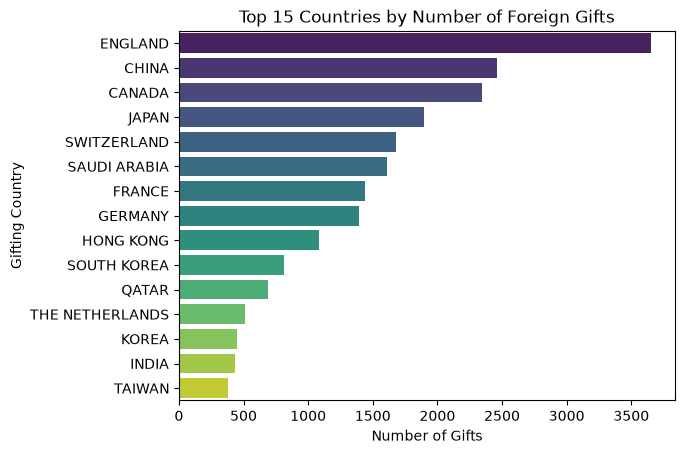

In [371]:
fig, ax = plt.subplots()
sns.countplot(
    data=gift,
    y="Country of Giftor",
    order=gift["Country of Giftor"].value_counts().iloc[:15].index,
    palette="viridis",
    ax=ax
)

ax.set(
    title="Top 15 Countries by Number of Foreign Gifts",
    xlabel="Number of Gifts",
    ylabel="Gifting Country"
)

plt.show()

The top 15 countries by the number of foreign gifts are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netheralands, Korea, India, and Taiwan (those seen in the chart above). 

/var/folders/zt/dp0g3ksj0xxd26j6gz893ycm0000gn/T/ipykernel_94704/3575042867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


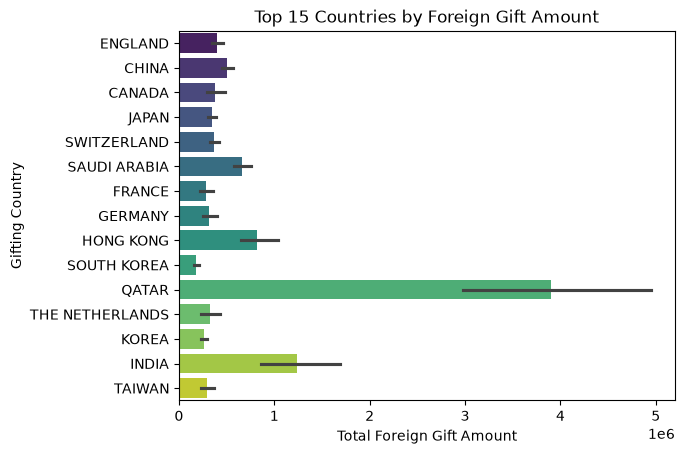

In [372]:
fig, ax = plt.subplots()
sns.barplot(
    data=gift,
    x = 'Foreign Gift Amount',
    y="Country of Giftor",
    order=gift["Country of Giftor"].value_counts().iloc[:15].index,
    palette="viridis",
    ax=ax
)

ax.set(
    title="Top 15 Countries by Foreign Gift Amount",
    xlabel="Total Foreign Gift Amount",
    ylabel="Gifting Country"
)

plt.show()

The top 15 countries in terms of amount given are: England, China, Canada, Japan, Swizerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan (Those seen in the bargraph above).

According to the barplot, Quatar is the country (giftor) with the largest money (monetry gift) provided in total. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 6d1c669c5ad896be4e90931a1b9e18352161ea91
- **AI tool and model used:** ChatGPT - 5.6 Luna

### *Prompts used

1. *I insterted (copy and pasted) my code solution from Phase one* What are some ways I could improve this code in order to better answer the following questions: * I inserted an image of the questions from Phase 1.* Review my code for errors and gove me a list of suggestions to make analysis more accurate. 
2. Provide me with these suggestions, but in a concise numbered list that I can add to the assignment.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Convert Foreign Gift Amount to numeric before applying transformations.
2. Handle zero and negative values before taking the log, since log(0) and log(negative values) are undefined.
3. For the top 15 countries by amount, use groupby() and sum() to calculate the total amount given by each country.
4. Sort the country totals in descending order and select the top 15 countries.
5. For the KDE plots, calculate a separate bandwidth for each gift type based on that group's sample size and standard deviation.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject |I decided to accept AI's suggestion to Convert the gift amount variable to numeric first because it makes transformations such as representing the data in its log form, less prone to errors since we ensure that each data point is a numeric entry. I verifies this by running the resulting final (improved) code and checking the dtypes of each variable. |
| 2 | Accept / modify / reject | I decided to accept AI's suggestion to Use groupby().sum() for countries where I am trying to find the total amount donated. In my original code, I did not use this, and did not find the correct values. By using the sum() function, I verified that the resulting graph showed the correct values of the total Gift by each country.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

gift.shape:
(28221, 10)
gift.dtypes:
ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object


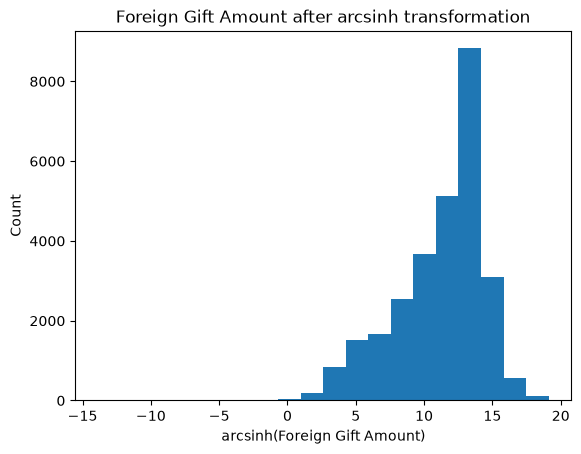

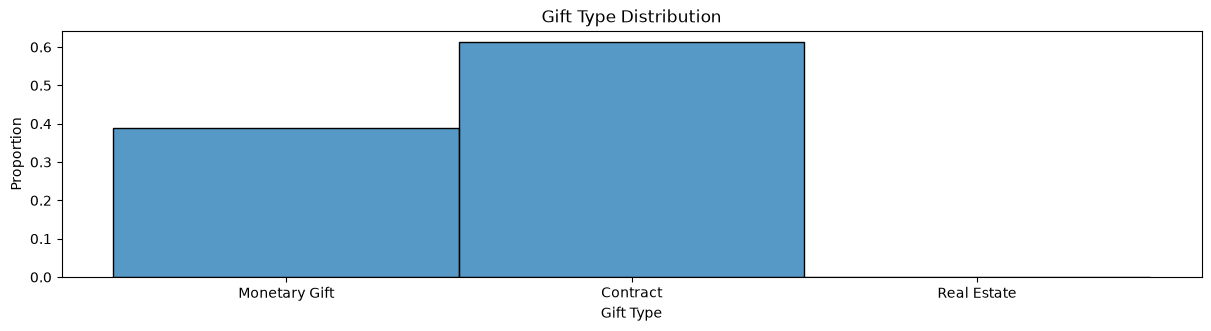

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


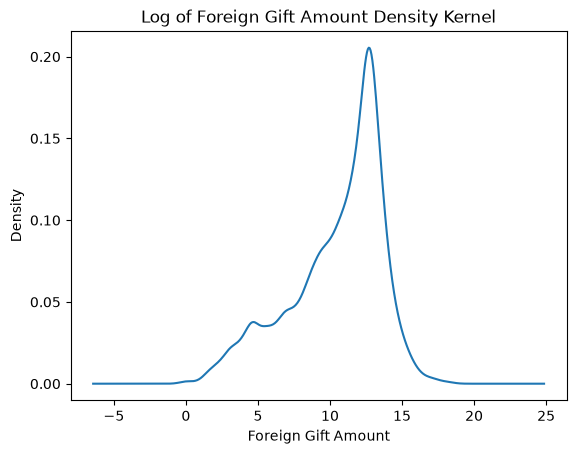

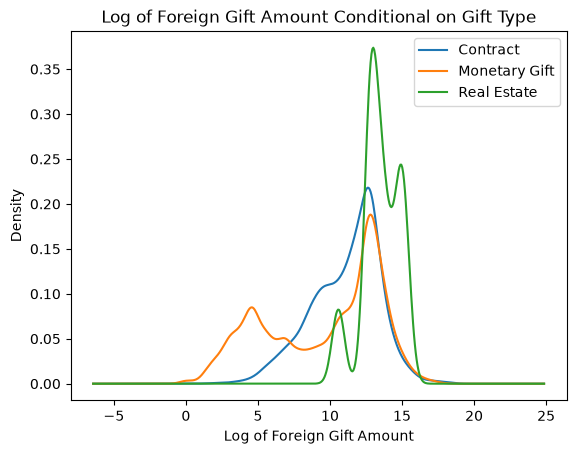

/var/folders/zt/dp0g3ksj0xxd26j6gz893ycm0000gn/T/ipykernel_94704/4070816237.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


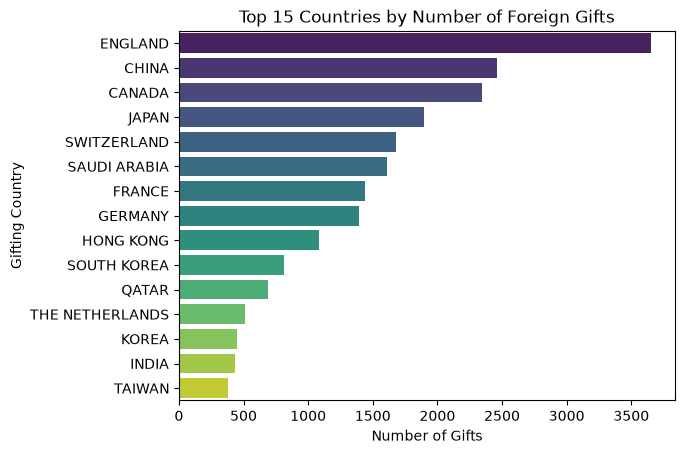

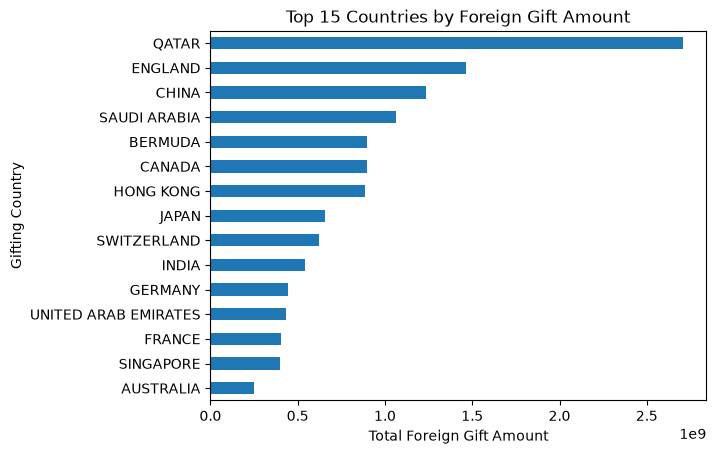

In [373]:
# Your Phase 2 solution to the problem goes here.
gift = pd.read_csv('ForeignGifts_edu.csv')

gift["Country of Giftor"].unique()

print("gift.shape:")
print(gift.shape)

print("gift.dtypes:")
print(gift.dtypes)

gift.head()

gift["Foreign Gift Amount"] = pd.to_numeric(
    gift["Foreign Gift Amount"], errors='coerce'
)

gift["Foreign_Gift_Amount_arcsinh"] = np.arcsinh(
    gift["Foreign Gift Amount"]
)

gift["Foreign_Gift_Amount_arcsinh"].hist(
    bins=20,
    grid=False
)

plt.title("Foreign Gift Amount after arcsinh transformation")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()


x = gift["Gift Type"].dropna().sample(
    28221, random_state=10
).to_numpy()

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 3.2),
    layout="constrained"
)

sns.histplot(
    data=gift,
    x="Gift Type",
    stat="proportion",
    ax=ax
)

ax.set(
    title="Gift Type Distribution",
    xlabel="Gift Type"
)

plt.show()


x = pd.to_numeric(
    gift["Foreign Gift Amount"],
    errors='coerce'
).dropna().to_numpy()

gift["Foreigngiftlog"] = np.log(
    gift["Foreign Gift Amount"].replace(0, np.nan)
)

x = gift["Foreigngiftlog"].dropna().to_numpy()

N = len(x)

sample_sd = np.std(x, ddof=1)

h_s = 1.06 * sample_sd * N**(-1 / 5)

grid = np.linspace(
    x.min() - 2 * sample_sd,
    x.max() + 2 * sample_sd,
    500
)


def normal_kernel(center, bandwidth):

    z = (grid - center) / bandwidth

    return (
        np.exp(-(z**2) / 2)
        / (bandwidth * np.sqrt(2 * np.pi))
    )


kde = sum(
    normal_kernel(value, h_s)
    for value in x
) / N

ax = sns.lineplot(
    x=grid,
    y=kde
)

ax.set(
    title="Log of Foreign Gift Amount Density Kernel",
    xlabel="Foreign Gift Amount",
    ylabel="Density"
)

plt.show()


fig, ax = plt.subplots()

for gift_type, group in gift.groupby("Gift Type"):

    x_sub = group["Foreigngiftlog"].dropna().to_numpy()

    N_sub = len(x_sub)

    estimate = sum(
        normal_kernel(value, h_s)
        for value in x_sub
    ) / N_sub

    sns.lineplot(
        x=grid,
        y=estimate,
        label=str(gift_type),
        ax=ax
    )

ax.set(
    title="Log of Foreign Gift Amount Conditional on Gift Type",
    xlabel="Log of Foreign Gift Amount",
    ylabel="Density"
)

plt.show()


fig, ax = plt.subplots()

sns.countplot(
    data=gift,
    y="Country of Giftor",
    order=gift["Country of Giftor"].value_counts().iloc[:15].index,
    palette="viridis",
    ax=ax
)

ax.set(
    title="Top 15 Countries by Number of Foreign Gifts",
    xlabel="Number of Gifts",
    ylabel="Gifting Country"
)

plt.show()


country_amount = (
    gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots()

country_amount.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set(
    title="Top 15 Countries by Foreign Gift Amount",
    xlabel="Total Foreign Gift Amount",
    ylabel="Gifting Country"
)

plt.show()


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements I made to my original code had to do mostly with numeric conversions and ensuring they happened correctly and accurately according to the question I was asked. First, I added code to convert the gift amount varibale and coerce it into a numeric data type. This was especially important because for this graph, we used the log of the data, which can only be accurately calculated if the data type is properly listed as numeric. Secondly, I corrected a mistake in my code, where I did not properly use the total gift amount per country. To correct this I used the sum() function and made my graph and analysis more accurately tailored to the question asked. One mistake/limitation of AI in this assignment is that sometimes it would not actually answer the question being asked and instead would offer suggestions that go above and beyond the requirements of this assignment, which in the real world would be difficult to adopt AI for simple tasks. One concern I have is that the gift type proportions bar graph does not show the amount of Real Estate type gifts given because of the scale and the fact there is such little Real estate gifts. I would want to have a graph that shows these values exist, because now it just looks like there is none in that category. 